# 1. Problem definition and research question

## Problem Definition

Preparing meals at home is an important part of household food behavior. Families differ in how often they prepare dinner at home and how much they spend on food. Looking at these patterns can help us better understand the relationship between home meal preparation and household food spending.

The purpose of this project is to examine whether the frequency of preparing dinner at home is associated with household food spending among U.S. households.

### Research Question

**How is the frequency of preparing dinner at home associated with household food spending among US. households?**
This question may be useful for households, researchers, and organizations interested in understanding household food behavior and spending patterns.

# 2. Data description

### 2.1 Data Source

This project uses data from the U.S. Department of Agriculture (USDA) National Household Food Acquisition and Purchase Survey (FoodAPS).

FoodAPS provides information about foods acquired by U.S. households, where the foods were obtained, how much was paid, and selected household characteristics.

The public-use FoodAPS data are organized into multiple related datasets. For this project, three datasets were selected because they contain the household characteristics and food spending information needed to answer the research question.

### 2.2 Web Data Acquisition

The FoodAPS data were obtained from the USDA Economic Research Service website using web scraping. Python's `requests` library was used to access the public FoodAPS webpage, and `BeautifulSoup` was used to parse the page and locate the CSV data download. The data files were then downloaded, extracted, and loaded into pandas for analysis.

In [60]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd
import zipfile
import io

In [61]:
## Download the FoodAPS data from the USDA website
page_url = "https://www.ers.usda.gov/data-products/foodaps-national-household-food-acquisition-and-purchase-survey"

soup = BeautifulSoup(requests.get(page_url).text, "html.parser")

link = soup.find("a", href=lambda x: x and "csv-data-files.zip" in x.lower())
csv_url = urljoin(page_url, link["href"])
print(csv_url)

## Download the zip file and extract its contents
data = requests.get(csv_url).content
with zipfile.ZipFile(io.BytesIO(data)) as z:
    z.extractall("foodaps_data")

print("FoodAPS data downloaded!")

https://www.ers.usda.gov/media/5594/csv-data-files.zip?v=24222
FoodAPS data downloaded!


### 2.3 Datasets Used

Three FoodAPS datasets were selected for this project:

**1. Household dataset (`faps_household_puf.csv`)**

This is the main household-level dataset. It contains the household identifier, dinner preparation information, household size, income, and other household characteristics.

**2. Food-at-Home Event dataset (`faps_fahevent_puf.csv`)**

This dataset contains food-at-home acquisition events. A household can have multiple records, so the spending amounts are aggregated by household.

**3. Food-Away-from-Home Event dataset (`faps_fafhevent_puf.csv`)**

This dataset contains food-away-from-home acquisition events. A household can also have multiple records in this dataset, so spending is aggregated by household before merging.

These three datasets were selected because together they provide the variables needed to examine dinner preparation and total household food spending.

In [62]:
household = pd.read_csv("foodaps_data/faps_household_puf.csv")
fah = pd.read_csv("foodaps_data/faps_fahevent_puf.csv")
fafh = pd.read_csv("foodaps_data/faps_fafhevent_puf.csv")

print("Household:", household.shape)
print("FAH:", fah.shape)
print("FAFH:", fafh.shape)

Household: (4826, 279)
FAH: (15998, 73)
FAFH: (39120, 82)


### 2.4 Key Variables

The main variables selected for this analysis are:

- `hhnum`: Household identification number.
- `nmealshome`: Frequency of preparing dinner at home.
- `hhsize`: Number of people in the household.
- `inchhavg_r`: Average monthly household income.
- `ndinnersouthh`: Dinners eaten outside the home.
- `totalpaid`: Amount paid during FAH or FAFH food acquisition events.

For easier interpretation, these variables were renamed in the analysis.

The main independent variable is `number_of_dinner_prepare_at_home`.

The dependent variable is `total_food_spending`, which is created by combining Food-at-Home and Food-Away-from-Home spending.

# 3. Data Cleaning and Preparation

The three FoodAPS datasets required cleaning before analysis. Only the variables needed for the research question were selected.

The variables were renamed to make them easier to understand. Special negative survey codes were treated as missing values so that they would not be included as actual numeric observations.

Because the FAH and FAFH datasets contain multiple food events for the same household, spending was aggregated by household ID before the datasets were merged.

Finally, a new variable called `total_food_spending` was created by combining Food-at-Home and Food-Away-from-Home spending.

In [63]:
## 3.1. Select variables of interest and rename them for clarity
columns = [
    "hhnum",
    "nmealshome",
    "hhsize",
    "inchhavg_r",
    "ndinnersouthh"
]

df = household[columns].copy()

# Rename the variables for clarity.
df = df.rename(columns={
    "hhnum"         : "household_id",
    "nmealshome"    : "number_of_dinner_prepare_at_home",
    "hhsize"        : "household_size",
    "inchhavg_r"    : "monthly_household_income",
    "ndinnersouthh" : "dinner_eaten_out"
})


df.head()
df.shape


(4826, 5)

In [64]:
## 3.2. Handle missing values and negative values
for column in df.columns:
    if column != "hhnum":
        df.loc[df[column] < 0, column] = np.nan

df.isnull().sum()


household_id                           0
number_of_dinner_prepare_at_home       4
household_size                         0
monthly_household_income               0
dinner_eaten_out                    1010
dtype: int64

In [65]:
# 3.3. Aggregate Food-at-Home Spending and Food-Away-from-Home spending

## Food at home spending by household aggregated by household id
fah_spending = (
    fah.groupby("hhnum")["totalpaid"]
       .sum(min_count=1)
       .reset_index()
)

fah_spending = fah_spending.rename(
    columns={
        "hhnum": "household_id",
        "totalpaid": "food_at_home_spending"}
)

fah_spending.head()

## Food away from home spending by household aggregated by household id

fafh_spending = (
    fafh.groupby("hhnum")["totalpaid"]
       .sum(min_count=1)
       .reset_index()
)

fafh_spending = fafh_spending.rename(
    columns={
        "hhnum": "household_id",
        "totalpaid": "food_away_from_home_spending"}
)


In [66]:
# 3.4. Merge household, FAH, and FAFH datasets into a single dataframe
df = df.merge(
    fah_spending,
    on="household_id",
    how="left"
)

df = df.merge(
    fafh_spending,
    on="household_id",
    how="left"
)

print(df.shape)
df.head()


(4826, 7)


,household_id,number_of_dinner_prepare_at_home,household_size,monthly_household_income,dinner_eaten_out,food_at_home_spending,food_away_from_home_spending
0,100012.0,9.0,5.0,4667.33,1.0,133.57,28.90
1,100015.0,5.0,1.0,1200.00,NaN,40.56,32.43
2,100024.0,3.0,2.0,5024.50,0.0,82.97,72.84
3,100026.0,7.0,2.0,1800.00,2.0,122.95,45.91
4,100028.0,7.0,7.0,3998.00,0.0,88.99,122.51


In [67]:
## 3.5. Create Total Food Spending
df["total_food_spending"] = (
    df["food_at_home_spending"].fillna(0) +
    df["food_away_from_home_spending"].fillna(0)
)

df[[
    "household_id",
    "number_of_dinner_prepare_at_home",
    "food_at_home_spending",
    "food_away_from_home_spending",
    "total_food_spending"
]].head()


,household_id,number_of_dinner_prepare_at_home,food_at_home_spending,food_away_from_home_spending,total_food_spending
0,100012.0,9.0,133.57,28.90,162.47
1,100015.0,5.0,40.56,32.43,72.99
2,100024.0,3.0,82.97,72.84,155.81
3,100026.0,7.0,122.95,45.91,168.86
4,100028.0,7.0,88.99,122.51,211.50


# 4. Visualization and Insights

Exploratory data analysis was performed to understand the distributions and relationships among the variables before interpreting the regression results.

## 4.1 Description Statistics

In [79]:
analysis_df = df[
    ["number_of_dinner_prepare_at_home", "total_food_spending"]
].dropna()

analysis_df.describe()

,number_of_dinner_prepare_at_home,total_food_spending
count,4822.000000,4822.000000
mean,5.229780,151.854023
std,2.607944,133.736838
min,0.000000,0.000000
25%,4.000000,59.975000
50%,5.000000,120.040000
75%,7.000000,208.287500
max,20.000000,2060.670000


The descriptive statistics show that households prepared dinner at home an average of approximately 5.23 times, while average recorded total food spending was approximately $151.85. There is considerable variation in food spending across households, with some households reporting much higher spending than others.

## 4.2. Distribution of Dinner Preparation

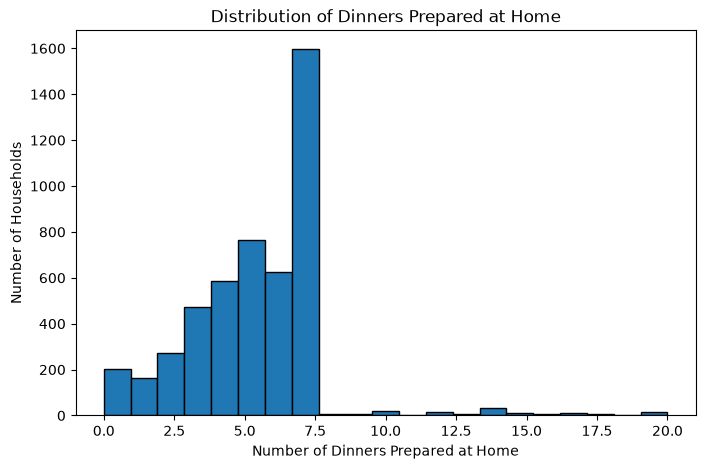

In [80]:
plt.figure(figsize=(8, 5))
plt.hist(analysis_df["number_of_dinner_prepare_at_home"], bins=21, edgecolor="black")
plt.xlabel("Number of Dinners Prepared at Home")
plt.ylabel("Number of Households")
plt.title("Distribution of Dinners Prepared at Home")
plt.show()


The histogram shows that most households reported preparing dinner at home several times during the observation period, with observations concentrated around the middle-to-upper portion of the distribution. A relatively small number of households reported much higher values. These high values should be interpreted according to the FoodAPS coding definition for the variable.

## 4.3 Correlation Analysis

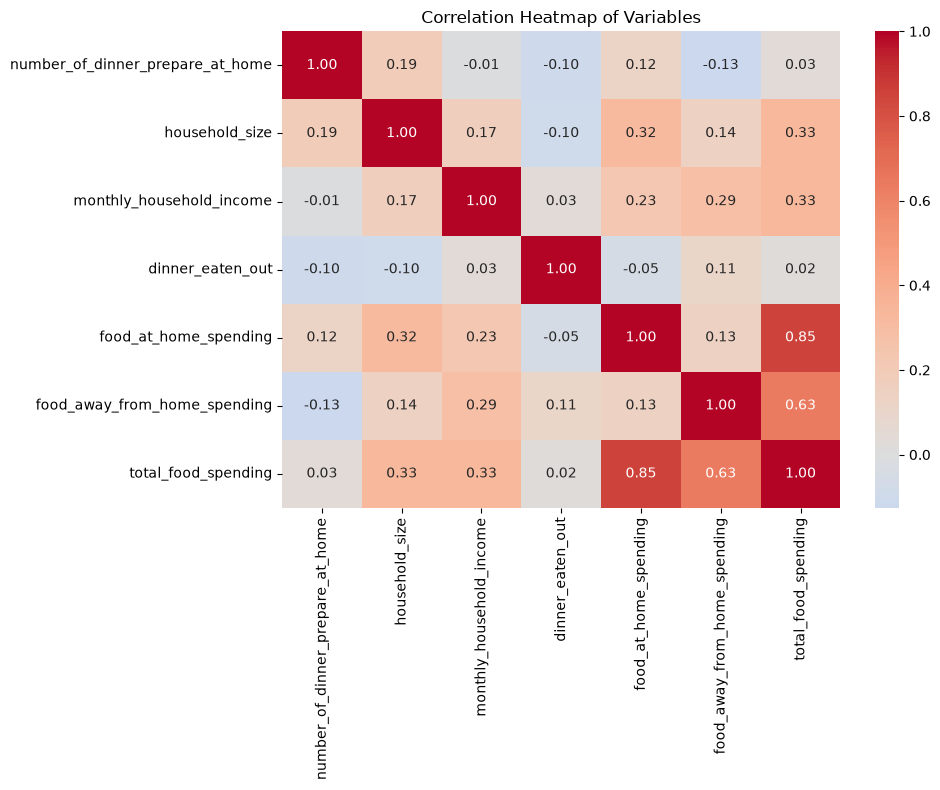

In [81]:
correlation_variables = df[[
    "number_of_dinner_prepare_at_home",
    "household_size",
    "monthly_household_income",
    "dinner_eaten_out",
    "food_at_home_spending",
    "food_away_from_home_spending",
    "total_food_spending"
]]

correlation_matrix = correlation_variables.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",center = 0)
plt.title("Correlation Heatmap of Variables")
plt.tight_layout()
plt.show()



The correlation between dinner preparation and total food spending is approximately 0.03, indicating very little linear relationship between these two variables.
Dinner preparation has a positive correlation with Food-at-Home spending and a negative correlation with Food-Away-from-Home spending. Household size and income show stronger positive relationships with total food spending than dinner preparation frequency.

## 4.4. Simple Linear Regression

In [82]:
X = analysis_df[["number_of_dinner_prepare_at_home"]]
y = analysis_df["total_food_spending"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R-squared:", model.score(X, y))

Intercept: 143.02576846494654
Coefficient: 1.6880737751617003
R-squared: 0.001083620291339682


The simple linear regression produced an intercept of approximately
$143.03 and a coefficient of approximately +$1.69.

This means that each additional dinner prepared at home was associated
with an estimated $1.69 increase in recorded household food spending.

However, the R² value was approximately 0.0011, meaning that dinner
preparation frequency alone explained only about 0.11% of the variation
in total food spending.

Therefore, dinner preparation frequency by itself has very little ability
to explain differences in total household food spending.

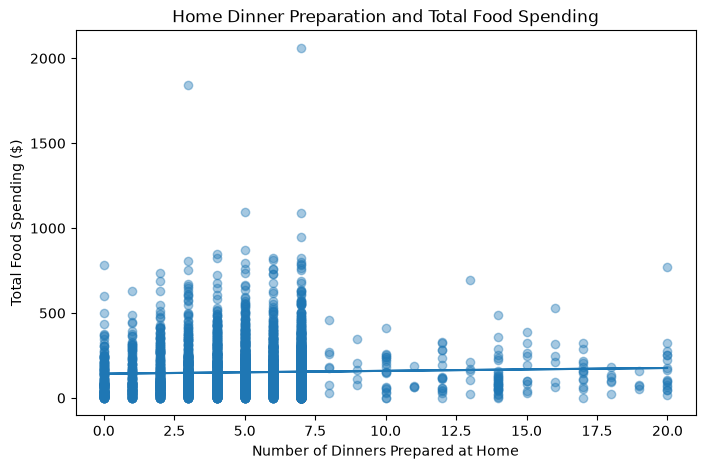

In [83]:
plt.figure(figsize=(8, 5))

# Scatterplot
plt.scatter(
    analysis_df["number_of_dinner_prepare_at_home"],
    analysis_df["total_food_spending"],
    alpha=0.4
)

# Regression line
plt.plot(
    analysis_df["number_of_dinner_prepare_at_home"],
    model.predict(X)
)

plt.xlabel("Number of Dinners Prepared at Home")
plt.ylabel("Total Food Spending ($)")
plt.title("Home Dinner Preparation and Total Food Spending")

plt.show()

The scatterplot shows that household food spending varies widely across different levels of dinner preparation. The regression line is nearly flat, which is consistent with the very weak linear relationship found in the correlation and regression analysis.

## 4.5 Multiple linear Regression

### 4.5 Multiple Linear Regression

Because household food spending may also be related to household size and income, a second regression model was created that included these variables along with dinner preparation frequency.

In [85]:
multiple_df = df[
    [
        "number_of_dinner_prepare_at_home",
        "household_size",
        "monthly_household_income",
        "total_food_spending"
    ]
].dropna()

multiple_df.head()

X_multi = multiple_df[
    [
        "number_of_dinner_prepare_at_home",
        "household_size",
        "monthly_household_income"
    ]
]

y_multi = multiple_df["total_food_spending"]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("Intercept:", multi_model.intercept_)

for variable, coefficient in zip(X_multi.columns, multi_model.coef_):
    print(variable, ":", coefficient)

print("R-squared:", multi_model.score(X_multi, y_multi))

Intercept: 52.629837879676415
number_of_dinner_prepare_at_home : -0.9706896866823101
household_size : 22.56023171557278
monthly_household_income : 0.010077329796029488
R-squared: 0.18731965873395784


After household size and monthly household income were included in the model, the coefficient for dinner preparation was approximately -$0.97.

Household size had a coefficient of approximately $22.56, while monthly household income had a coefficient of approximately $0.0101 per dollar of income.

The multiple regression had an R² of approximately 0.1873. This means that the variables included in this model explained about 18.73% of the variation in recorded household food spending.

The change in the dinner-preparation coefficient between the simple and multiple models suggests that household characteristics such as size and income are important to consider when examining food spending.

# 5. Storytelling and Narrative

The results show that dinner preparation frequency alone has very little linear relationship with total household food spending. The correlation between the two variables was close to zero, and the simple regression explained only about 0.11% of the variation in food spending.

The analysis becomes more informative when household size and income are considered. After adding these variables, the regression model explained approximately 18.73% of the variation in total food spending.

These results suggest that household food spending is related to multiple household characteristics rather than dinner preparation frequency alone.

The analysis does not show that preparing dinner at home causes food spending to increase or decrease. It only identifies associations within the FoodAPS data.

# 6. Limitation, Ethics, and Reflection

There are several limitations to this analysis. FoodAPS is observational survey data, so the relationships found in this project should not be interpreted as evidence of causation.

Some variables also contained missing responses or special survey codes that had to be handled during data cleaning. In addition, food spending varies considerably across households, and some households have much higher recorded spending than others.

The models used in this project also do not include every factor that may be related to household food spending. Food prices, geographic location, household composition, dietary preferences, and access to food retailers may also affect household spending.

The data were obtained from publicly available USDA FoodAPS resources. The web acquisition process was limited to accessing the public webpage and downloading the public-use data needed for this analysis.

If this project were expanded, I would examine Food-at-Home and Food-Away-from-Home spending separately and explore additional household characteristics.

# 7. Code and Transparency

The complete Python code used for data acquisition, cleaning, analysis, visualization, and regression is available in my GitHub repository. GitHub: https://github.com/gaguegue-glitch/project1. The repository contains the Jupyter Notebook used to complete the FoodAPS analysis.

### Data Source

The data used in this project come from the U.S. Department of Agriculture (USDA), Economic Research Service, National Household Food Acquisition and Purchase Survey (FoodAPS). FoodAPS contains information about food purchases and acquisitions by U.S. households, including Food-at-Home (FAH) and Food-Away-from-Home (FAFH) acquisitions. The public-use FoodAPS data were accessed from the USDA Economic Research Service website. FoodAPS Data Source:
https://www.ers.usda.gov/data-products/foodaps-national-household-food-acquisition-and-purchase-survey

## AI Usage Disclosure

OpenAI ChatGPT (GPT-5.6 Sol) was used during this project to assist with brainstorming, code troubleshooting, organizing the analysis workflow, explaining statistical results, and improving the clarity of written interpretations.
I reviewed the analysis, executed the Python code, examined the results, and take responsibility for the final submitted work.

## References

Page, E. T., Newman, C., Guthrie, J., & Mancino, L. (2019). The National Household Food Acquisition and Purchase Survey: Innovations and research insights. Applied Economic Perspectives and Policy, 41(2), 215–234. https://doi.org/10.1093/aepp/ppy034

Volpe, R., Cai, X., Tseng, M., Zeballos, E., & Sinclair, W. (2022). Changes in the local food-at-home environment, Supplemental Nutrition Assistance Program participation, and dietary quality: Evidence from FoodAPS. Journal of the Agricultural and Applied Economics Association, 1, 151–164. https://doi.org/10.1002/jaa2.19

Hillier, A., Smith, T. E., & Whiteman, E. D. (2017). Discrete choice model of food store trips using National Household Food Acquisition and Purchase Survey (FoodAPS). International Journal of Environmental Research and Public Health, 14(10), 1133. https://doi.org/10.3390/ijerph14101133